In [1]:
# 1. Import libraries

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# 2. Load cleaned reviews

df = pd.read_csv("../data/cleaned_reviews.csv")

df.head()

,userName,content,score,at,thumbsUpCount,review_length,sentiment
0,Dawn Lowe,its hard for older peeps to work on this app,3,2026-06-19 00:29:09,0,44,Neutral
1,Luz Hernandez,sucks,1,2026-06-18 10:20:40,0,5,Negative
2,Mandi,simple process very pleased,5,2026-06-18 04:41:24,0,27,Positive
3,Allen Tartet,"thus, great service.",5,2026-06-18 04:02:35,0,20,Positive
4,Ray “Turtleeyes” DeWitt,helpful app,5,2026-06-16 23:06:36,0,11,Positive


In [3]:
# 3. Inspect columns and shape

print(df.shape)
print(df.columns)

(500, 7)
Index(['userName', 'content', 'score', 'at', 'thumbsUpCount', 'review_length',
       'sentiment'],
      dtype='object')


In [4]:
# 4. Basic rating-based sentiment check

def rating_sentiment(score):
    if score <= 2:
        return "Negative"
    elif score == 3:
        return "Neutral"
    else:
        return "Positive"

df["rating_sentiment"] = df["score"].apply(rating_sentiment)

df["rating_sentiment"].value_counts()

rating_sentiment
Negative    287
Positive    188
Neutral      25
Name: count, dtype: int64

In [5]:
# 5. Text sentiment validation layer
# This checks whether the written review appears positive, negative, or unclear.

positive_words = [
    "good", "great", "helpful", "wonderful", "excellent", "easy",
    "love", "perfect", "awesome", "simple", "useful", "convenient"
]

negative_words = [
    "sucks", "doesn't work", "does not work", "terrible", "bad",
    "horrible", "useless", "frustrating", "hate", "awful",
    "broken", "worst", "problem", "issue", "bug", "crash", "slow"
]

def detect_text_sentiment(text):
    text = str(text).lower()

    if any(word in text for word in positive_words):
        return "Positive Text"
    elif any(word in text for word in negative_words):
        return "Negative Text"
    else:
        return "Unclear Text"

df["text_sentiment"] = df["content"].apply(detect_text_sentiment)

df["text_sentiment"].value_counts()

text_sentiment
Unclear Text     253
Positive Text    153
Negative Text     94
Name: count, dtype: int64

In [6]:
# 6. Rating/Text mismatch check

df["rating_text_check"] = "Aligned"

df.loc[
    (df["score"] <= 2) & (df["text_sentiment"] == "Positive Text"),
    "rating_text_check"
] = "Rating/Text Mismatch"

df.loc[
    (df["score"] >= 4) & (df["text_sentiment"] == "Negative Text"),
    "rating_text_check"
] = "Rating/Text Mismatch"

df["rating_text_check"].value_counts()

rating_text_check
Aligned                 465
Rating/Text Mismatch     35
Name: count, dtype: int64

In [7]:
# 7. Create operational reviews dataframe
# These are the reviews we want to investigate for operational issues.

operational_reviews = df[
    (df["score"] <= 3) &
    (df["rating_text_check"] == "Aligned")
].copy()

operational_reviews.shape

(286, 10)

In [8]:
# 8. Rule-based issue classifier

def classify_issue(text):
    text = str(text).lower()

    if any(word in text for word in [
        "payment", "pay rent", "rent", "processing fee", "fee",
        "charge", "charges", "transaction", "bank", "card", "pay"
    ]):
        return "Payments"

    elif any(word in text for word in [
        "login", "log in", "logout", "logged out", "sign in",
        "signin", "password", "reset password", "can't login",
        "cannot login", "access", "account"
    ]):
        return "Authentication"

    elif any(word in text for word in [
        "maintenance", "repair", "request", "service request",
        "work order", "callback", "call back", "no response"
    ]):
        return "Maintenance"

    elif any(word in text for word in [
        "doesn't work", "does not work", "hard to use", "difficult to use",
        "confusing", "interface", "ui", "upload", "bright", "screen",
        "navigate", "navigation", "usability", "complicated", "app", "bad", "sucks"
    ]):
        return "UI / Usability"

    elif any(word in text for word in [
        "slow", "lag", "lagging", "loading", "takes forever",
        "freezing", "frozen"
    ]):
        return "Performance"

    elif any(word in text for word in [
        "won't open", "will not open", "doesn't open", "does not open",
        "crash", "crashes", "crashing", "bug", "blank", "white screen",
        "error", "glitch"
    ]):
        return "Stability"

    else:
        return "Other Operational Issue"

In [9]:
# 9. Apply classifier

operational_reviews["issue_category"] = operational_reviews["content"].apply(classify_issue)

operational_reviews["issue_category"].value_counts()

issue_category
Payments                   102
Authentication              66
UI / Usability              55
Other Operational Issue     46
Maintenance                 12
Stability                    4
Performance                  1
Name: count, dtype: int64

In [10]:
# 10. Calculate issue category percentages

issue_counts = operational_reviews["issue_category"].value_counts().reset_index()
issue_counts.columns = ["issue_category", "review_count"]

issue_counts["percentage"] = round(
    (issue_counts["review_count"] / issue_counts["review_count"].sum()) * 100,
    2
)

issue_counts

,issue_category,review_count,percentage
0,Payments,102,35.66
1,Authentication,66,23.08
2,UI / Usability,55,19.23
3,Other Operational Issue,46,16.08
4,Maintenance,12,4.20
5,Stability,4,1.40
6,Performance,1,0.35


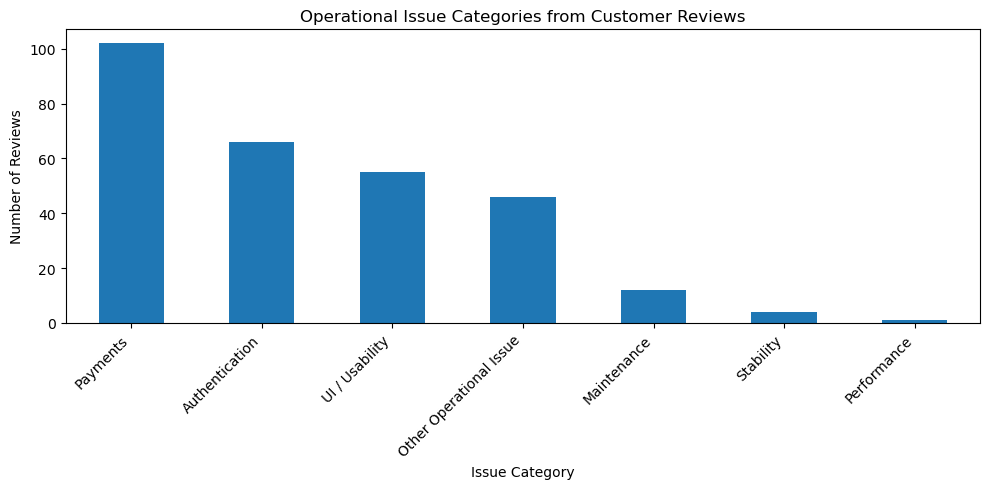

In [11]:
# 11. Visualize issue categories

issue_counts.plot(
    kind="bar",
    x="issue_category",
    y="review_count",
    legend=False,
    figsize=(10, 5)
)

plt.title("Operational Issue Categories from Customer Reviews")
plt.xlabel("Issue Category")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [12]:
# 12. Inspect Other Operational Issues
# This helps us discover missing themes before moving to LLM-based detection.

other_reviews = operational_reviews[
    operational_reviews["issue_category"] == "Other Operational Issue"
]

other_reviews[["score", "content"]].sample(
    min(20, len(other_reviews)),
    random_state=42
)

,score,content
459,2,Expensive
275,3,struggle with notifications but otherwise easy...
277,1,will not load
487,1,stupid and irrelevant
382,2,trying to link to my chrome Book not working
468,1,Worst experience imaginable
65,1,A whole Unprofessional mess.
165,1,They make it so difficult to get any assistanc...
86,1,It's not worked in over a year then I get real...
56,1,can't get it to work


In [13]:
# 13. Save classified reviews for next stage

operational_reviews.to_csv("../data/classified_operational_reviews.csv", index=False)

issue_counts.to_csv("../data/issue_category_summary.csv", index=False)

print("Files saved successfully.")

Files saved successfully.
